In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

In [ ]:
# Load the cleaned dataset
file_path = "cleaned_dataset_no_outliers.csv"
df = pd.read_csv(file_path)
df.head()

C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\948472943.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000254,254 Augusta,False,False,11.7,12.467000,0.170000,0.137000,JPL 32,2459000.5,...,0.000004,0.000040,0.000044,0.000021,6.240000e-09,1.150000e-09,0.000068,0.000005,MBA,0.40909
1,2000473,473 Nolli (1901 GC),False,False,11.7,12.394000,0.138000,0.138000,JPL 34,2459000.5,...,0.000005,0.000019,0.000029,0.000021,1.320000e-08,1.520000e-09,0.000092,0.000011,MBA,0.37280
2,2000719,719 Albert (1911 MT),True,False,15.4,7.581494,0.145937,-0.167142,JPL 214,2459000.5,...,0.000003,0.000017,0.000017,0.000003,3.910000e-09,3.310000e-10,0.000010,0.000002,AMO,0.39148
3,2000724,724 Hapag (1911 NC),False,False,13.8,9.492000,0.103000,0.198000,JPL 29,2459000.5,...,0.000005,0.000019,0.000021,0.000007,1.240000e-08,1.550000e-09,0.000026,0.000009,MBA,0.48206
4,2000728,728 Leonisis (1912 NU),False,False,12.9,5.887000,0.160000,0.481000,JPL 41,2459000.5,...,0.000003,0.000048,0.000052,0.000020,6.060000e-09,1.080000e-09,0.000069,0.000005,MBA,0.43402


In [3]:
# Check unique values in the column
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

# Check data types
print(df[["potentially_hazardous", "near_earth_object"]].dtypes)
# Convert all values to consistent binary format (0 = Non-Hazardous, 1 = Hazardous)
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()  # Convert all to uppercase for consistency

# Define mapping
hazardous_mapping = {
    "TRUE": 1, "FALSE": 0,
    "N": 0  # Assuming 'N' means non-hazardous
}

# Apply mapping
df["potentially_hazardous"] = df["potentially_hazardous"].map(hazardous_mapping).astype(int)
# Convert boolean values to integer (0/1)
df["near_earth_object"] = df["near_earth_object"].astype(int)
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())


Unique values in 'potentially_hazardous': [False True 'False' 'True' 'FALSE' 'N' 'TRUE']
Unique values in 'near_earth_object': [False  True]
potentially_hazardous    object
near_earth_object          bool
dtype: object
Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]


In [5]:
df.dtypes

asteroid_id                               int64
asteroid_name                            object
near_earth_object                         int32
potentially_hazardous                     int32
absolute_magnitude                      float64
diameter_km                             float64
surface_reflectivity                    float64
diameter_uncertainty_km                 float64
orbit_solution_id                        object
orbit_epoch                             float64
orbit_epoch_mjd                           int64
orbit_epoch_calendar                      int64
orbital_eccentricity                    float64
semi_major_axis_au                      float64
perihelion_distance_au                  float64
orbital_inclination_deg                 float64
longitude_ascending_node_deg            float64
argument_perihelion_deg                 float64
mean_anomaly_deg                        float64
aphelion_distance_au                    float64
mean_motion_deg_day                     

In [6]:
# Drop unnecessary columns (categorical, IDs, and labels)
# excluded_columns = ['asteroid_id', 'asteroid_name', 'near_earth_object', 'potentially_hazardous', 
#                     'orbit_solution_id', 'asteroid_class']
excluded_columns = ['asteroid_id', 'asteroid_name', 'orbit_solution_id', 'asteroid_class']

df_numeric = df.drop(columns=excluded_columns)

In [7]:
df_numeric.head()

,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_epoch,orbit_epoch_mjd,orbit_epoch_calendar,orbital_eccentricity,...,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,orbit_fit_rms
0,0,0,11.7,12.467000,0.170000,0.137000,2459000.5,59000,20200531,0.122053,...,7.680000e-08,0.000004,0.000040,0.000044,0.000021,6.240000e-09,1.150000e-09,0.000068,0.000005,0.40909
1,0,0,11.7,12.394000,0.138000,0.138000,2459000.5,59000,20200531,0.106437,...,1.210000e-07,0.000005,0.000019,0.000029,0.000021,1.320000e-08,1.520000e-09,0.000092,0.000011,0.37280
2,1,0,15.4,7.581494,0.145937,-0.167142,2459000.5,59000,20200531,0.546558,...,5.810000e-08,0.000003,0.000017,0.000017,0.000003,3.910000e-09,3.310000e-10,0.000010,0.000002,0.39148
3,0,0,13.8,9.492000,0.103000,0.198000,2459000.5,59000,20200531,0.250901,...,1.270000e-07,0.000005,0.000019,0.000021,0.000007,1.240000e-08,1.550000e-09,0.000026,0.000009,0.48206
4,0,0,12.9,5.887000,0.160000,0.481000,2459000.5,59000,20200531,0.088027,...,6.580000e-08,0.000003,0.000048,0.000052,0.000020,6.060000e-09,1.080000e-09,0.000069,0.000005,0.43402


In [8]:
# Normalize the data using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

In [9]:
# Apply PCA with 2 components
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(df_scaled)

In [10]:

# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
pca_3d_result = pca_3d.fit_transform(df_scaled)


In [11]:
# Compute explained variance
explained_variance_2d = np.sum(pca_2d.explained_variance_ratio_) * 100
explained_variance_3d = np.sum(pca_3d.explained_variance_ratio_) * 100

In [12]:
# Find the minimum number of components required to retain 95% variance
pca_full = PCA()
pca_full.fit(df_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # +1 because index starts from 0


In [13]:
# Extract top three eigenvalues
top_eigenvalues = pca_full.explained_variance_[:3]


In [14]:
# Create DataFrame for visualization
pca_2d_df = pd.DataFrame(pca_2d_result, columns=['PC1', 'PC2'])
pca_3d_df = pd.DataFrame(pca_3d_result, columns=['PC1', 'PC2', 'PC3'])


In [15]:
# Display results
explained_variance_2d, explained_variance_3d, n_components_95, top_eigenvalues

(43.09717634762742,
 55.10627308288277,
 15,
 array([7.91969676, 7.59532881, 4.32328655]))

C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\735799957.py:9: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_dataset_no_outliers.csv")


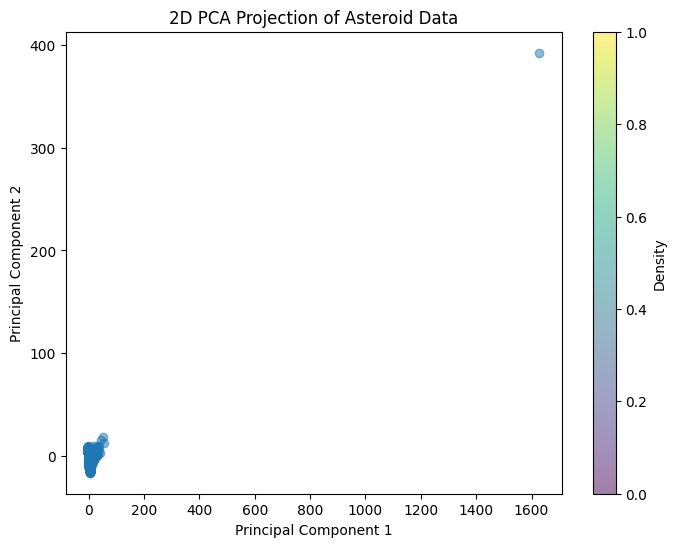

Variance retained in 2D PCA: 45.52%


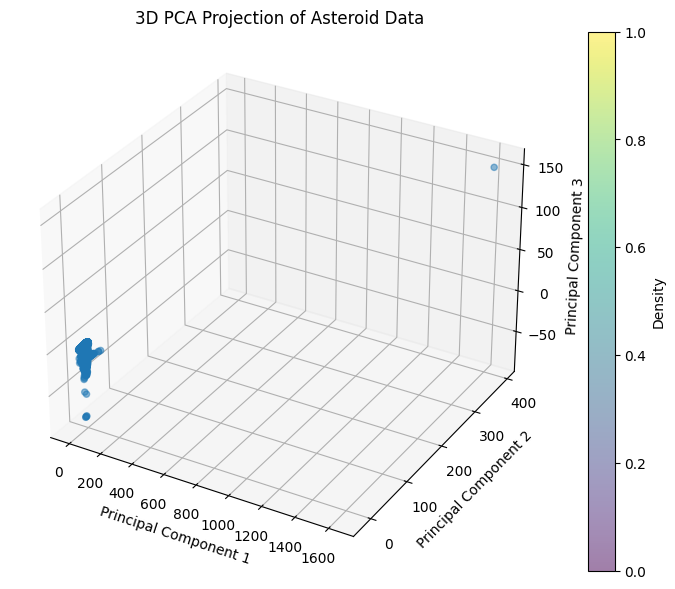

Variance retained in 3D PCA: 58.24%
Number of components required to retain 95% variance: 13


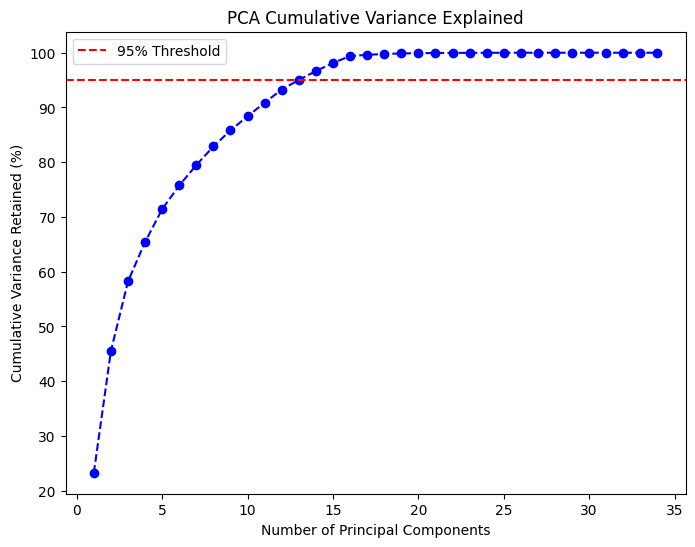

Top 3 Eigenvalues: [7.91754106 7.5599325  4.32327861]


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load cleaned dataset
df = pd.read_csv("cleaned_dataset_no_outliers.csv")

# Drop non-numeric and identifier columns
excluded_columns = ['asteroid_id', 'asteroid_name', 'near_earth_object', 'potentially_hazardous',
                    'orbit_solution_id', 'asteroid_class']
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.difference(excluded_columns)

# Standardize the numeric columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_columns])

### **PCA with 2 Components**
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Plot 2D PCA visualization
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], alpha=0.5, cmap="coolwarm")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Asteroid Data")
plt.colorbar(label="Density")
plt.show()

# Percentage of variance explained
variance_2d = np.sum(pca_2d.explained_variance_ratio_) * 100
print(f"Variance retained in 2D PCA: {variance_2d:.2f}%")

### **PCA with 3 Components**
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], alpha=0.5, cmap="coolwarm")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Projection of Asteroid Data")
plt.colorbar(sc, label="Density")
plt.show()

# Percentage of variance explained
variance_3d = np.sum(pca_3d.explained_variance_ratio_) * 100
print(f"Variance retained in 3D PCA: {variance_3d:.2f}%")

### **Finding Optimal Number of Components for 95% Variance**
pca_full = PCA()
pca_full.fit(df_scaled)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components to retain 95% variance
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components required to retain 95% variance: {optimal_components}")

# Plot cumulative variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--', color='b')
plt.axhline(y=95, color='r', linestyle='--', label="95% Threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Retained (%)")
plt.title("PCA Cumulative Variance Explained")
plt.legend()
plt.show()

### **Extracting Top 3 Eigenvalues**
eigenvalues = pca_full.explained_variance_
top_3_eigenvalues = eigenvalues[:3]
print(f"Top 3 Eigenvalues: {top_3_eigenvalues}")


In [17]:
# Convert PCA-transformed data into DataFrame
df_pca_3d = pd.DataFrame(df_pca_3d, columns=[f'PC{i+1}' for i in range(3)])
df_pca_13d = pd.DataFrame(pca_full.transform(df_scaled)[:, :13], columns=[f'PC{i+1}' for i in range(13)])

# Save the PCA-transformed data to CSV
df_pca_3d.to_csv("pca_3d_transformed.csv", index=False)
df_pca_13d.to_csv("pca_13d_transformed.csv", index=False)

print("PCA-transformed datasets saved successfully!")


PCA-transformed datasets saved successfully!


In [18]:
import pandas as pd

# Load the cleaned dataset
file_path = "cleaned_dataset_no_outliers.csv"  # Update path if needed
df = pd.read_csv(file_path)

# Define the relevant columns for PCA
pca_columns = [
    "orbital_eccentricity", "semi_major_axis_au", "perihelion_distance_au",
    "orbital_inclination_deg", "aphelion_distance_au", "mean_motion_deg_day",
    "orbital_period_days", "orbital_period_years", "earth_moid_au",
    "uncertainty_eccentricity", "uncertainty_semi_major_axis", 
    "uncertainty_perihelion_distance", "uncertainty_orbital_inclination",
    "uncertainty_aphelion_distance", "surface_reflectivity", "diameter_km"
]

# Select only these columns
df_pca = df[pca_columns].dropna()  # Drop missing values for PCA

# Display the first 5 rows
df_pca.head()


C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\2889432785.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,orbital_eccentricity,semi_major_axis_au,perihelion_distance_au,orbital_inclination_deg,aphelion_distance_au,mean_motion_deg_day,orbital_period_days,orbital_period_years,earth_moid_au,uncertainty_eccentricity,uncertainty_semi_major_axis,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_aphelion_distance,surface_reflectivity,diameter_km
0,0.122053,2.194870,1.926980,4.511842,2.462760,0.303103,1187.713307,3.251782,0.915786,3.460000e-08,5.560000e-09,7.680000e-08,0.000004,6.240000e-09,0.170000,12.467000
1,0.106437,2.663625,2.380116,12.930272,2.947133,0.226722,1587.844633,4.347282,1.400960,4.550000e-08,1.190000e-08,1.210000e-07,0.000005,1.320000e-08,0.138000,12.394000
2,0.546558,2.638602,1.196452,11.567485,4.080752,0.229955,1565.522356,4.286167,0.203482,2.180000e-08,2.530000e-09,5.810000e-08,0.000003,3.910000e-09,0.145937,7.581494
3,0.250901,2.454535,1.838690,11.712441,3.070380,0.256301,1404.598964,3.845582,0.855046,5.330000e-08,9.920000e-09,1.270000e-07,0.000005,1.240000e-08,0.103000,9.492000
4,0.088027,2.253746,2.055355,4.257149,2.452137,0.291304,1235.821636,3.383495,1.072540,2.940000e-08,5.570000e-09,6.580000e-08,0.000003,6.060000e-09,0.160000,5.887000


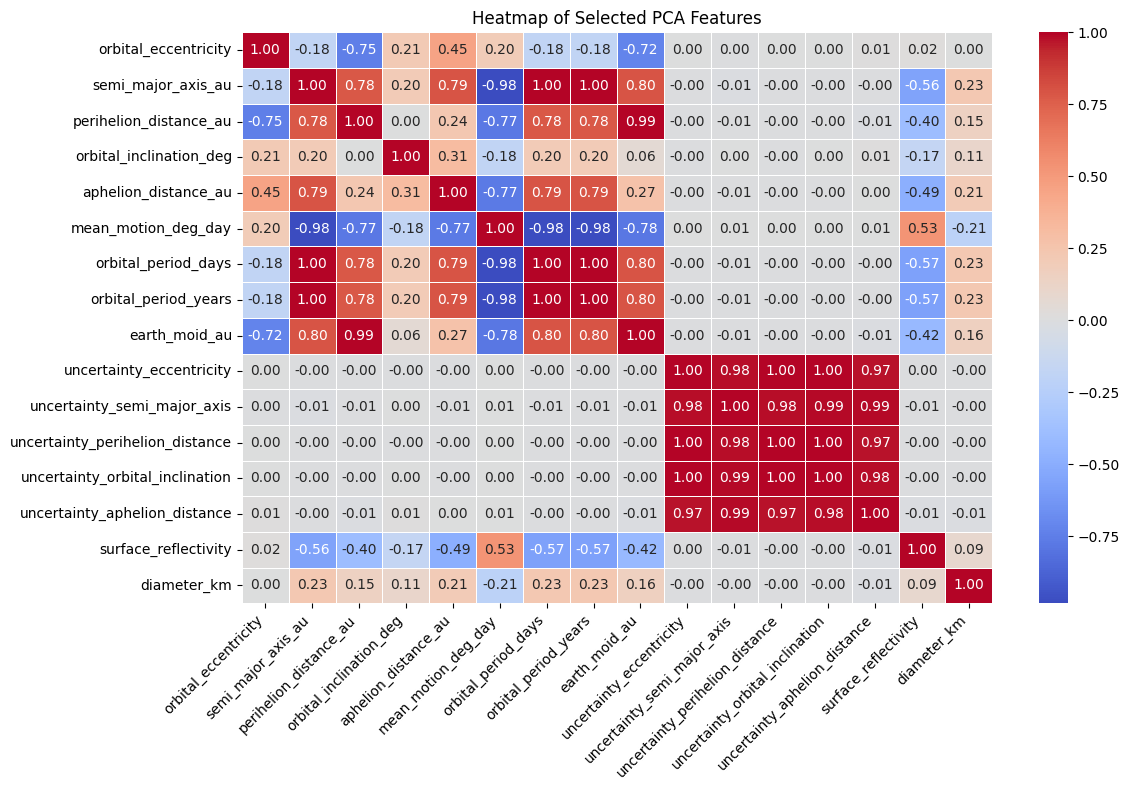

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df_pca_selected = df[pca_columns]

# Compute correlation matrix
correlation_matrix = df_pca_selected.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap of Selected PCA Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Display the plot
plt.show()


In [19]:
from sklearn.preprocessing import StandardScaler

# Normalize the data
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

# Convert back to DataFrame
df_pca_scaled = pd.DataFrame(df_pca_scaled, columns=pca_columns)

# Display first 5 rows of standardized data
df_pca_scaled.head()


,orbital_eccentricity,semi_major_axis_au,perihelion_distance_au,orbital_inclination_deg,aphelion_distance_au,mean_motion_deg_day,orbital_period_days,orbital_period_years,earth_moid_au,uncertainty_eccentricity,uncertainty_semi_major_axis,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_aphelion_distance,surface_reflectivity,diameter_km
0,-0.291087,-2.397732,-1.500222,-0.918714,-2.269374,2.826904,-2.311403,-2.311403,-1.606950,-0.002863,-0.01163,-0.003369,-0.005573,-0.01805,2.176784,3.972760
1,-0.487774,-0.760093,-0.241623,0.417490,-0.949011,0.610152,-0.783430,-0.783430,-0.237642,-0.002863,-0.01163,-0.003369,-0.005573,-0.01805,1.302616,3.941431
2,5.055819,-0.847513,-3.529286,0.201183,2.141142,0.703975,-0.868671,-0.868671,-3.617286,-0.002863,-0.01163,-0.003369,-0.005573,-0.01805,1.519439,1.876129
3,1.331832,-1.490567,-1.745449,0.224191,-0.613050,1.468588,-1.483186,-1.483186,-1.778376,-0.002863,-0.01163,-0.003369,-0.005573,-0.01805,0.346496,2.696029
4,-0.719657,-2.192044,-1.143658,-0.959140,-2.298331,2.484462,-2.127693,-2.127693,-1.164543,-0.002863,-0.01163,-0.003369,-0.005573,-0.01805,1.903607,1.148932


In [20]:
from sklearn.decomposition import PCA

# Perform PCA with 2 components
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(df_pca_scaled)

# Compute explained variance
explained_variance_2d = np.sum(pca_2d.explained_variance_ratio_) * 100
print(f"Variance retained in 2D PCA: {explained_variance_2d:.2f}%")


Variance retained in 2D PCA: 70.89%


In [21]:
# Perform PCA with 3 components
pca_3d = PCA(n_components=3)
pca_3d_result = pca_3d.fit_transform(df_pca_scaled)

# Compute explained variance
explained_variance_3d = np.sum(pca_3d.explained_variance_ratio_) * 100
print(f"Variance retained in 3D PCA: {explained_variance_3d:.2f}%")


Variance retained in 3D PCA: 84.18%


In [22]:
import numpy as np

# Perform full PCA to find optimal dimensions
pca_full = PCA()
pca_full.fit(df_pca_scaled)

# Compute cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components needed to retain at least 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # +1 to convert index to count

print(f"Number of components required to retain 95% variance: {n_components_95}")


Number of components required to retain 95% variance: 5


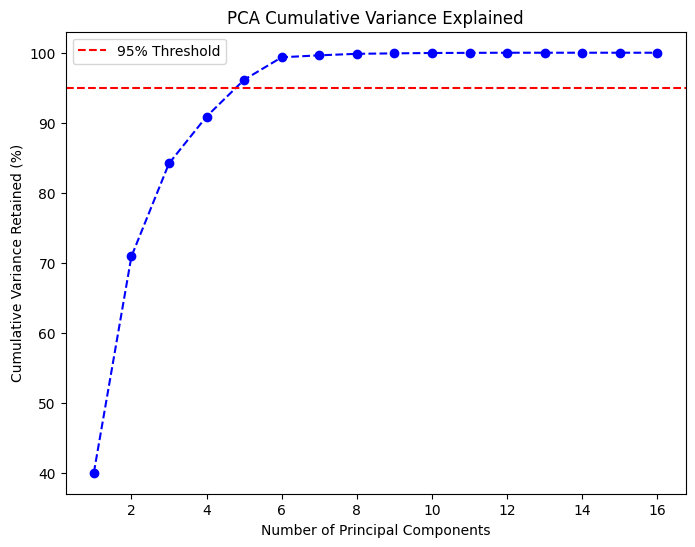

In [27]:
# Plot cumulative variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--', color='b')
plt.axhline(y=95, color='r', linestyle='--', label="95% Threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Retained (%)")
plt.title("PCA Cumulative Variance Explained")
plt.legend()
plt.show()

In [23]:
# Extract eigenvalues
top_eigenvalues = pca_full.explained_variance_[:3]

print(f"Top 3 Eigenvalues: {top_eigenvalues}")


Top 3 Eigenvalues: [6.40054296 4.9426261  2.12597506]


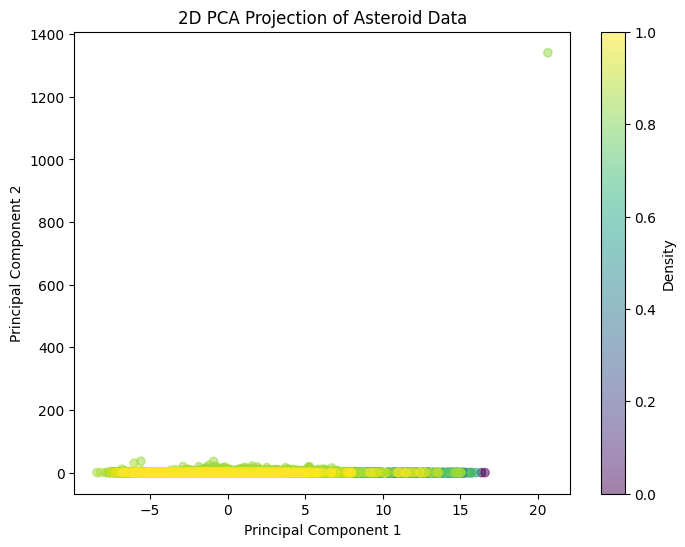

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame for visualization
pca_2d_df = pd.DataFrame(pca_2d_result, columns=['PC1', 'PC2'])

# Create a color scale based on density
colors = np.linspace(0, 1, len(pca_2d_df))

# Plot the 2D PCA projection with a color map
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_2d_df["PC1"], pca_2d_df["PC2"], c=colors, cmap="viridis", alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Asteroid Data")

# Add colorbar
plt.colorbar(scatter, label="Density")
plt.show()


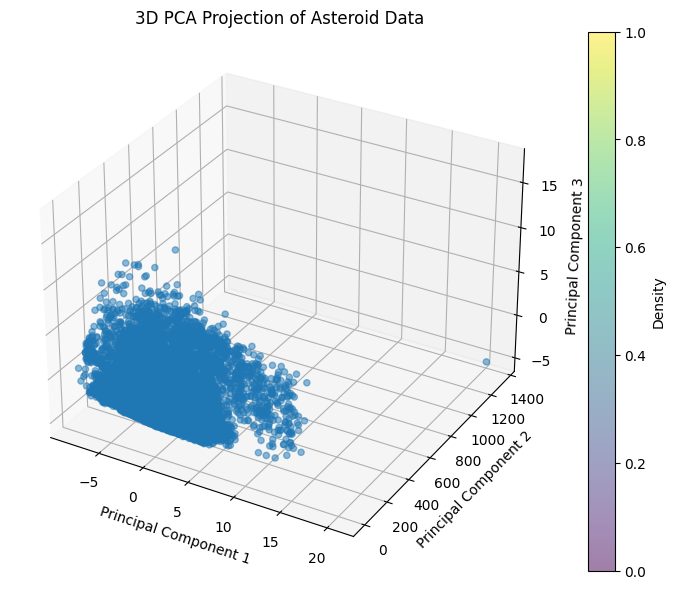

In [25]:
from mpl_toolkits.mplot3d import Axes3D

# Create DataFrame for visualization
pca_3d_df = pd.DataFrame(pca_3d_result, columns=['PC1', 'PC2', 'PC3'])

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pca_3d_df["PC1"], pca_3d_df["PC2"], pca_3d_df["PC3"], alpha=0.5, cmap="coolwarm")

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Projection of Asteroid Data")

plt.colorbar(sc, label="Density")
plt.show()


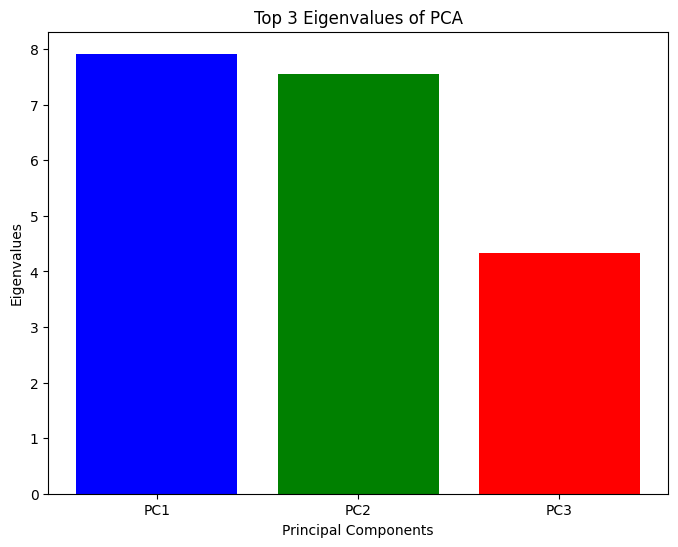

In [29]:
# Plot top 3 eigenvalues
plt.figure(figsize=(8, 6))
plt.bar(["PC1", "PC2", "PC3"], top_3_eigenvalues, color=['blue', 'green', 'red'])
plt.xlabel("Principal Components")
plt.ylabel("Eigenvalues")
plt.title("Top 3 Eigenvalues of PCA")
plt.show()

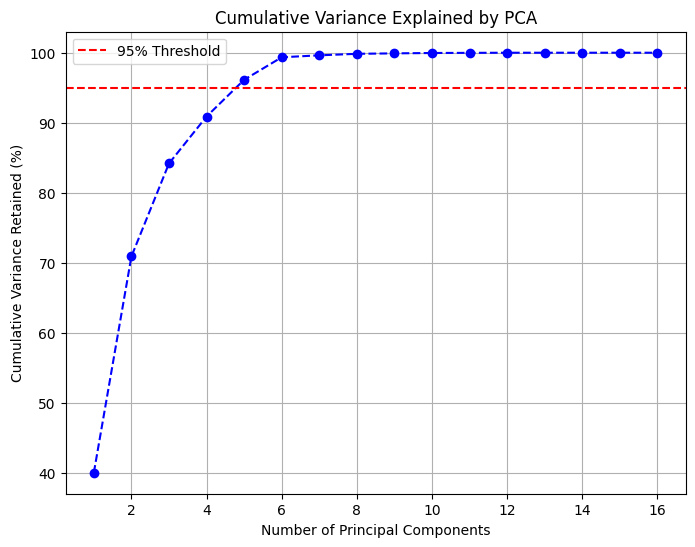

In [30]:


# Apply PCA
pca = PCA()
pca.fit(df_pca_scaled)

# Compute cumulative variance explained
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot Cumulative Variance Explained
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--', color='b')
plt.axhline(y=95, color='r', linestyle='--', label="95% Threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Retained (%)")
plt.title("Cumulative Variance Explained by PCA")
plt.legend()
plt.grid()
plt.show()


C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\199381994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=component_contributions.columns, y=component_contributions.iloc[0], palette="coolwarm")


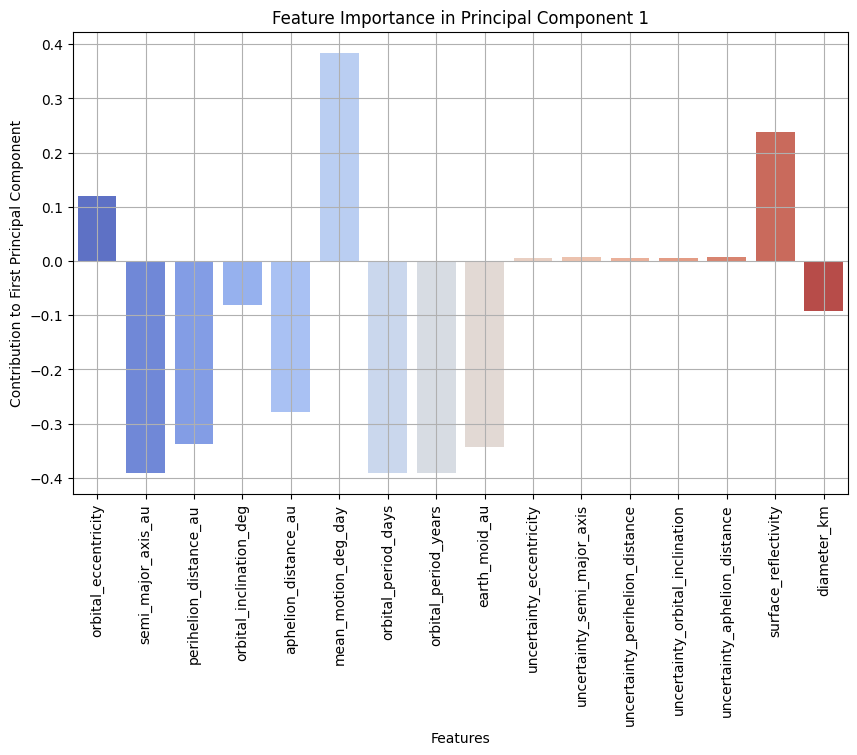

C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\199381994.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\199381994.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(component_contributions.columns, rotation=90)
C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\199381994.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\mihir\AppData\Local\Temp\ipykernel_38840\199381994.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(component_contributions.columns, rotation=90)
C:\Users\mihir\AppData\Local\Temp\ipykerne

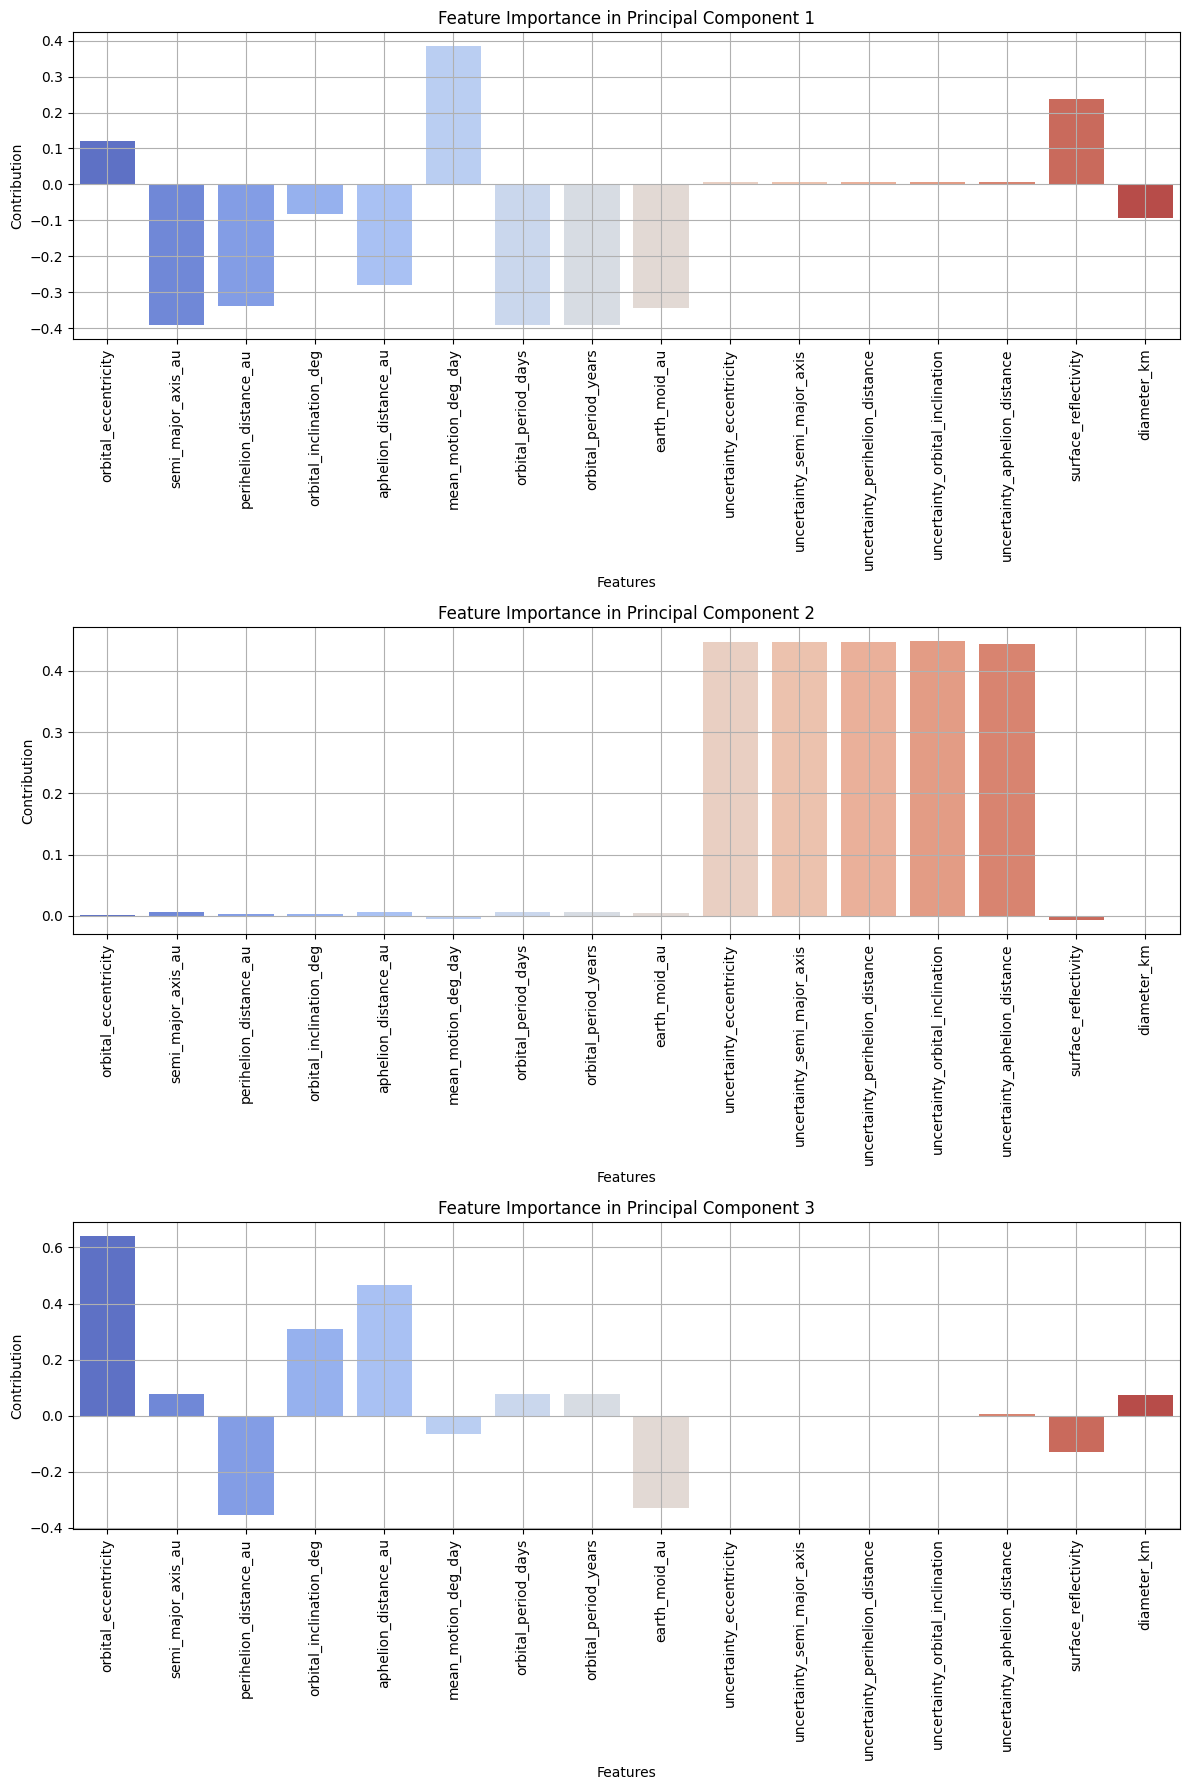

In [34]:
import seaborn as sns

# Extract feature contributions to the first principal component
component_contributions = pd.DataFrame(
    pca.components_, columns=pca_columns, index=[f'PC{i+1}' for i in range(len(pca_columns))]
)

# Plot Feature Contributions to First Principal Components
plt.figure(figsize=(10, 6))
sns.barplot(x=component_contributions.columns, y=component_contributions.iloc[0], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Contribution to First Principal Component")
plt.title("Feature Importance in Principal Component 1")
plt.grid()
plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

# Select the number of components you want to visualize
num_components = 3  # Change this if you want more PCs

# Create a subplot for each principal component
fig, axes = plt.subplots(nrows=num_components, figsize=(12, 6 * num_components))

for i in range(num_components):
    sns.barplot(
        x=component_contributions.columns, 
        y=component_contributions.iloc[i], 
        palette="coolwarm", 
        ax=axes[i]
    )
    axes[i].set_title(f"Feature Importance in Principal Component {i+1}")
    axes[i].set_xlabel("Features")
    axes[i].set_ylabel("Contribution")
    axes[i].set_xticklabels(component_contributions.columns, rotation=90)
    axes[i].grid()

plt.tight_layout()
plt.show()



# Clustering

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load cleaned dataset
df = pd.read_csv("cleaned_dataset_no_outliers.csv")

C:\Users\mihir\AppData\Local\Temp\ipykernel_18888\904750232.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_dataset_no_outliers.csv")


In [3]:
df.dtypes

asteroid_id                               int64
asteroid_name                            object
near_earth_object                          bool
potentially_hazardous                    object
absolute_magnitude                      float64
diameter_km                             float64
surface_reflectivity                    float64
diameter_uncertainty_km                 float64
orbit_solution_id                        object
orbit_epoch                             float64
orbit_epoch_mjd                           int64
orbit_epoch_calendar                      int64
orbital_eccentricity                    float64
semi_major_axis_au                      float64
perihelion_distance_au                  float64
orbital_inclination_deg                 float64
longitude_ascending_node_deg            float64
argument_perihelion_deg                 float64
mean_anomaly_deg                        float64
aphelion_distance_au                    float64
mean_motion_deg_day                     

In [4]:

# Drop non-numeric and identifier columns
drop_columns = ["asteroid_id", "asteroid_name", "orbit_solution_id", "asteroid_class", "potentially_hazardous", "near_earth_object"]
df_numeric = df.drop(columns=drop_columns, errors='ignore')

# Normalize the dataset
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

df_scaled.head()

,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_epoch,orbit_epoch_mjd,orbit_epoch_calendar,orbital_eccentricity,semi_major_axis_au,perihelion_distance_au,...,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,orbit_fit_rms
0,-5.305078,3.972760,2.176784,-1.405216,0.132042,0.132042,0.131871,-0.291087,-2.397732,-1.500222,...,-0.003369,-0.005573,-0.00867,0.013438,-0.056915,-0.01805,-0.013971,-0.018844,-0.022557,-2.148092
1,-5.305078,3.941431,1.302616,-1.401794,0.132042,0.132042,0.131871,-0.487774,-0.760093,-0.241623,...,-0.003369,-0.005573,-0.00867,0.013438,-0.056915,-0.01805,-0.013971,-0.018844,-0.022557,-2.635690
2,-0.674148,1.876129,1.519439,-2.445783,0.132042,0.132042,0.131871,5.055819,-0.847513,-3.529286,...,-0.003369,-0.005573,-0.00867,0.013438,-0.056915,-0.01805,-0.013971,-0.018844,-0.022557,-2.384703
3,-2.676712,2.696029,0.346496,-1.196515,0.132042,0.132042,0.131871,1.331832,-1.490567,-1.745449,...,-0.003369,-0.005573,-0.00867,0.013438,-0.056915,-0.01805,-0.013971,-0.018844,-0.022557,-1.167656
4,-3.803155,1.148932,1.903607,-0.228282,0.132042,0.132042,0.131871,-0.719657,-2.192044,-1.143658,...,-0.003369,-0.005573,-0.00867,0.013438,-0.056915,-0.01805,-0.013971,-0.018844,-0.022557,-1.813129


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# ===========================
# Step 1: Load and Prepare Data
# ===========================
# Load dataset
df = pd.read_csv("cleaned_dataset_no_outliers.csv")

# Drop non-numeric and identifier columns
drop_columns = ["asteroid_id", "asteroid_name", "orbit_solution_id", "asteroid_class", "potentially_hazardous", "near_earth_object"]
df_numeric = df.drop(columns=drop_columns, errors='ignore')

# Normalize data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# Apply PCA (Reduce to 3D for visualization & efficiency)
pca = PCA(n_components=3)
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=["PC1", "PC2", "PC3"])

print("Data Preparation Complete.")

# ===========================
# Step 2: K-Means Clustering
# ===========================

# Determine optimal 'k' using Silhouette Analysis
sil_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    sil_scores.append(silhouette_score(df_pca, labels))

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, sil_scores, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.show()

# Apply K-Means with Optimal k
optimal_k = k_values[np.argmax(sil_scores)]
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pca["Cluster"] = kmeans.fit_predict(df_pca)

# Visualize Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster"], palette="Set2", s=10)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker="X", label="Centroids")
plt.legend()
plt.title("K-Means Clustering (PCA Reduced)")
plt.show()

print(f"Optimal k = {optimal_k}")

# ===========================
# Step 3: Hierarchical Clustering (Sampling to Avoid Memory Issues)
# ===========================

# Sample 5,000 rows to generate a dendrogram
df_sample = df_pca.sample(n=5000, random_state=42)

# Generate Dendrogram
plt.figure(figsize=(10, 6))
linked = linkage(df_sample, method="ward")
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Sampled)")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Apply Hierarchical Clustering (on full dataset but with optimized number of clusters)
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
df_pca["Cluster_Hierarchical"] = hierarchical.fit_predict(df_pca)

# Visualize Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster_Hierarchical"], palette="Set1", s=10)
plt.title("Hierarchical Clustering (PCA Reduced)")
plt.show()

print("Hierarchical Clustering Completed.")

# ===========================
# Step 4: DBSCAN Clustering (Tuning Parameters)
# ===========================

# Apply DBSCAN
eps_value = 0.5  # Adjust based on dataset
min_samples_value = 10  # Higher value avoids too many small clusters
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
df_pca["Cluster_DBSCAN"] = dbscan.fit_predict(df_pca)

# Count clusters
num_clusters_dbscan = len(set(df_pca["Cluster_DBSCAN"])) - (1 if -1 in df_pca["Cluster_DBSCAN"] else 0)

# Visualize DBSCAN Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster_DBSCAN"], palette="tab10", s=10)
plt.title(f"DBSCAN Clustering (Found {num_clusters_dbscan} clusters)")
plt.show()

print("DBSCAN Clustering Completed.")


C:\Users\mihir\AppData\Local\Temp\ipykernel_15528\2500576782.py:16: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_dataset_no_outliers.csv")


Data Preparation Complete.


KeyboardInterrupt: 